In [1]:
%matplotlib widget
import pickle
import typing as t

import matplotlib.pyplot as plt
import numpy as np
import requests
import xobjects as xo
import xpart as xp
import xtrack as xt
import xcoll as xc
from cpymad.madx import Madx

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.optimize import minimize
import itertools

import re
import os
import pickle
from cpymad.madx import Madx

import warnings
from IPython.display import display, HTML, Markdown, clear_output

display(HTML("<style>.rendered_html { font-size: 17px; }</style>"))
display(HTML("<style>.container { width:90% !important; }</style>"))

def printmd(string):
    display(Markdown(string))
# warnings.filterwarnings('ignore')

from elements import TECA

import elements as el
import optimisers as op
import importlib


# Creating the initial conditions close to the crystal

In [2]:
qy_LSA_FlatTop = 22.1008
qx_LSA_FlatTop = 22.0395

In [3]:
# importlib.reload(op)
# import optimisers

# Creating the orthogonal knobs in LSS4
line = el.initialise_lineQ22()
op.match_chromaticityQ22(line, qx=qx_LSA_FlatTop, qy=qy_LSA_FlatTop)


Loading line from dict:   0%|          | 0/4598 [00:00<?, ?it/s]

Done loading line from dict.           


Slicing line:   0%|          | 0/4598 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/4601 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/4603 [00:00<?, ?it/s]

Non-channeled particle lost at element ap.do.mst21774_aper (index 1122) on turn 0
Adjusting ap.do.mst21774_aper: increasing rectangular aperture.
The line already has an associated tracker
Non-channeled particle lost at element ap.up.mst21779_aper (index 1125) on turn 0
Adjusting ap.up.mst21779_aper: increasing rectangular aperture.
The line already has an associated tracker
Non-channeled particle lost at element ap.do.mst21779_aper (index 1130) on turn 0
Adjusting ap.do.mst21779_aper: increasing rectangular aperture.
The line already has an associated tracker
Non-channeled particle lost at element ap.up.mst21794_aper (index 1133) on turn 0
Adjusting ap.up.mst21794_aper: increasing rectangular aperture.
The line already has an associated tracker
Non-channeled particle lost at element ap.do.mst21794_aper (index 1138) on turn 0
Adjusting ap.do.mst21794_aper: increasing rectangular aperture.
The line already has an associated tracker
Non-channeled particle not lost during tracking.
The li

In [4]:
bumpers = {
    "mpsh.41402": "kmpsh41402",
    "mplh.41658": "kmplh41658",
    "mplh.41994": "kmplh41994",
    "mpsh.42198": "kmpsh42198"
}

def plot_bump(ax, show_elements=True, **kwargs):
    tw = line.twiss(continue_on_closed_orbit_error=True, method ="4d").to_pandas()
    tw.index = tw.name
    tw.plot(x='s', y='x', ax=ax, **kwargs)
    if show_elements:
        ax.axvline(tw.loc['TECA.entry'].s, color='k', linestyle='--')
        for name in ['mpsh.41402', 'mplh.41658', 'mplh.41994', 'mpsh.42198']:
            ax.axvline(tw.loc[name].s, color='r', linestyle='--', label=name)
            ax.text(tw.loc[name].s, tw.x.max()/2, name, rotation=90, verticalalignment='bottom', horizontalalignment='right', color='red')

        for name in tw.loc['mpsh.41402':'mpsh.42198'].name:
            if 'q' in name:
                ax.axvline(tw.loc[name].s, color='g', linestyle='--', label=name)
                ax.text(tw.loc[name].s, tw.x.max()/2, name, rotation=90, verticalalignment='bottom', horizontalalignment='right', color='green')

    ax.set_xlim(3800, 4200)

# Horizontal knob

In [5]:
# fig, ax = plt.subplots()


# opt_x_LSS4 = op.normalized_x_knobLSS4(line)

# plot_bump(ax)

# settings = {}
# for name, knob in bumpers.items():
#     settings[name] = line.vv[knob]

# settings = pd.DataFrame(settings, index=['knob']).T
# settings.plot(kind='bar')

# import optimisers as op
# import importlib
# importlib.reload(op)

# Set the initial conditions
#optLSS4 = op.horizontal_bumpLSS4_MD(line, x_target = - 40e-3, px_target = -1.5e-3)
#optLSS4 = op.horizontal_bumpLSS4_MD(line)
optLSS4 = op.horizontal_bumpLSS4_MD(line)




optLSS4.log()
optLSS4.solve()

tw = line.twiss(continue_on_closed_orbit_error=True, method ="4d")

                                             
Optimize - start penalty: 0.4                               
Matching: model call n. 19 penalty = 5.0741e-15              
Optimize - end penalty:  5.07408e-15                            
                                             
Optimize - start penalty: 5.074e-15                          
Matching: model call n. 21 penalty = 5.0741e-15              
Optimize - end penalty:  5.07408e-15                            


In [6]:
tw_df = tw.to_pandas()
tw_df.index = tw_df.name
angle_at_TECA = tw_df.loc['TECA.entry'].px 
postion_at_TECA = tw_df.loc['TECA.entry'].x 


# What is the angle at TECA then????

In [7]:
TECA.tilt*1e3

np.float64(-0.88)

In [8]:
angle_at_TECA*1e3

np.float64(-0.8883580720614422)

In [9]:
(TECA.jaw -TECA.width)*1e3

np.float64(-39.800000000000004)

In [10]:
postion_at_TECA*1e3

np.float64(-39.99999999994707)

### Printing correctors values

In [11]:
from copy import copy

tab = line.get_table(attr=True)
line.vars.get_table()
tab.rows["mp.h\.2.*"].cols["k0l"]

bumpersLSS4 = list(line.vars.get_table().rows["kmp.h4.*[0-9]"].name)

for bumper, knob in bumpers.items():
    line.env[bumper + "_init"] = copy(line.vv[knob])


In [12]:
line.env["x_teca_knob"] = 1.0

In [13]:
for bumper in bumpers:
    line.vv[bumper] = bumper + "_init" + "*  x_teca_knob"
    print(bumper, line.vv[bumper])

mpsh.41402 -0.00030826188967394275
mplh.41658 -0.0004928762773793241
mplh.41994 -0.0005038850989651299
mpsh.42198 -9.624564390985305e-05


In [14]:
tw_df.to_csv('twiss_tableLSS4bumpON.csv', index=False)

## Ranges for correctors:

### MPLH [-7.0, 7.0]e-4
### MPSH [-5.0, 5.0]e-4

-0.00030826188967394275
-0.0004928762773793241
-0.0005038850989651299
-9.624564390985305e-05


<Axes: >

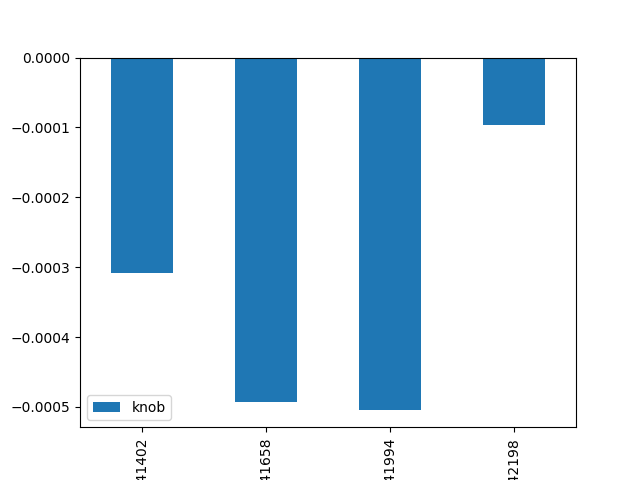

In [15]:
settings = {}
for name, knob in bumpers.items():
    settings[name] = line.vv[knob]
    print(settings[name])

settings = pd.DataFrame(settings, index=['knob']).T
settings.plot(kind='bar')

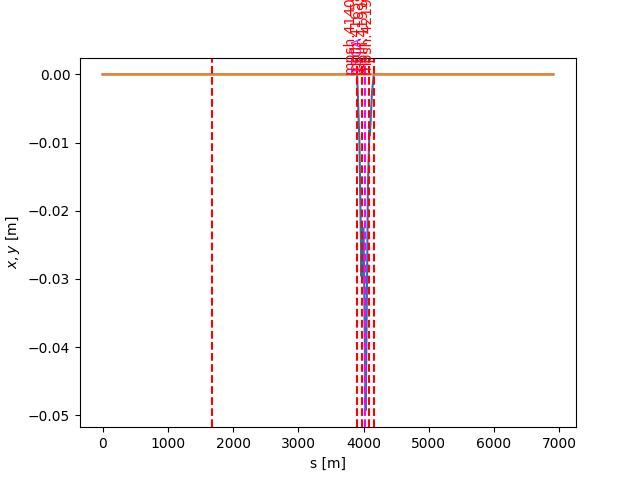

mpsh.41402 -0.00030826188967394275
mplh.41658 -0.0004928762773793241
mplh.41994 -0.0005038850989651299
mpsh.42198 -9.624564390985305e-05


In [16]:
tw_init = line.twiss(continue_on_closed_orbit_error=True, method = '4d')

plt.figure()
ax = plt.subplot(1, 1, 1)
plt.plot(tw_init.s, tw_init.x)
plt.plot(tw_init.s, tw_init.y)
plt.axvline(tw_init["s", "zs.21633"], color="red", ls="--", label="ZS entry")
plt.axvline(tw_init["s", "TECA.entry"], color="magenta", ls="--")
ax.text(
    tw_init["s", "TECA.entry"],
    tw_init["x"].max(),
    "TECA",
    rotation=90,
    verticalalignment='bottom',
    horizontalalignment='right',
    color='magenta'
)
plt.ylabel(r"$x,y$ [m]")
plt.xlabel("s [m]")
for name in ['mpsh.41402', 'mplh.41658', 'mplh.41994', 'mpsh.42198']:
    ax.axvline(tw_init['s', name], color='r', linestyle='--', label=name)
    ax.text(tw_init['s', name], tw_init['x'].max()/2, name, rotation=90, verticalalignment='bottom', horizontalalignment='right', color='red')

plt.show()

settings = {}
for name, knob in bumpers.items():
    settings[name] = line.vv[knob]
    print(name, settings[name])

# settings = pd.DataFrame(settings, index=['knob']).T
# settings.plot(kind='bar')
# plt.xlim(0,6900)


In [17]:
tw_df.to_pickle('twiss_tableLSS4bumpON.pckl')

#########

In [18]:
from elements import deltaP_P
#from elements import N_EX
N_EX = 4 *1e-6

# Compute the horizontal beam sigma (standard deviation) at TECA position, including dispersion
betx_teca = tw['betx', 'TECA.entry']
dx_teca = tw['dx', 'TECA.entry']
gamma_rel = line.particle_ref.gamma0
beta_rel = line.particle_ref.beta0
# Example normalized emittance (adjust if you have a different value)
en_x = N_EX * 0.1  # [m·rad]
emit_x = en_x / (beta_rel * gamma_rel)
# Assume relative momentum spread (adjust if you have a different value)
sigma_delta = deltaP_P
sigma_x_teca = np.sqrt(betx_teca * emit_x + (dx_teca * sigma_delta) ** 2)
print(f"Beam sigma_x at TECA.entry: {float(sigma_x_teca)*1e3:.3f} mm")
print(f"Beam 7 * sigma_x at TECA.entry: {float(7 * sigma_x_teca)*1e3:.3f} mm")

Beam sigma_x at TECA.entry: 2.010 mm
Beam 7 * sigma_x at TECA.entry: 14.068 mm


/var/folders/vc/njn3rgb96cq7_32jmcfzppkm0000gn/T/ipykernel_36097/2444422943.py:16: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(f"Beam sigma_x at TECA.entry: {float(sigma_x_teca)*1e3:.3f} mm")
/var/folders/vc/njn3rgb96cq7_32jmcfzppkm0000gn/T/ipykernel_36097/2444422943.py:17: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(f"Beam 7 * sigma_x at TECA.entry: {float(7 * sigma_x_teca)*1e3:.3f} mm")


In [19]:
sigma_x_teca * 1e3

LinkedArrayCpu([2.00970416])

In [20]:
sigma_x_teca_NO_DISPERSION = np.sqrt(betx_teca * emit_x)


In [21]:
sigma_x_teca_NO_DISPERSION * 1e3

LinkedArrayCpu([0.2483235])

In [22]:
betx_teca * emit_x

LinkedArrayCpu([6.16645611e-08])

In [23]:
(dx_teca * sigma_delta) ** 2

np.float64(3.977246254088031e-06)

### Creating a fine knob for x

                                             
Optimize - start penalty: 0.4195                            
Matching: model call n. 19 penalty = 1.7974e-10              
Optimize - end penalty:  1.79744e-10                            
mpsh.41402 2.2618864467583115e-05
mplh.41658 -2.6986338067485314e-06
mplh.41994 2.1779736377118302e-05
mpsh.42198 -1.6545776878214152e-05


<Axes: >

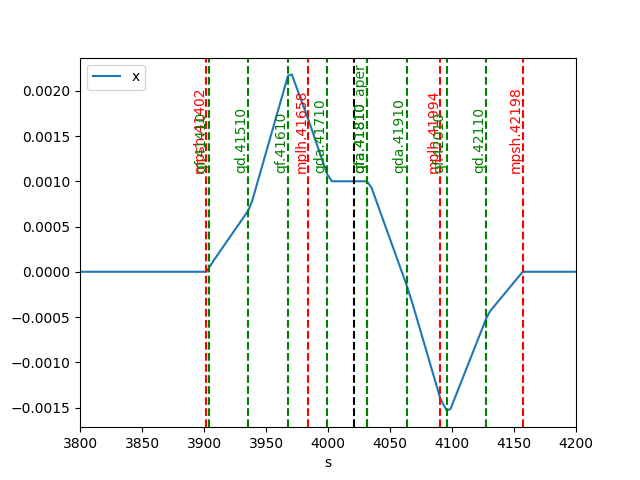

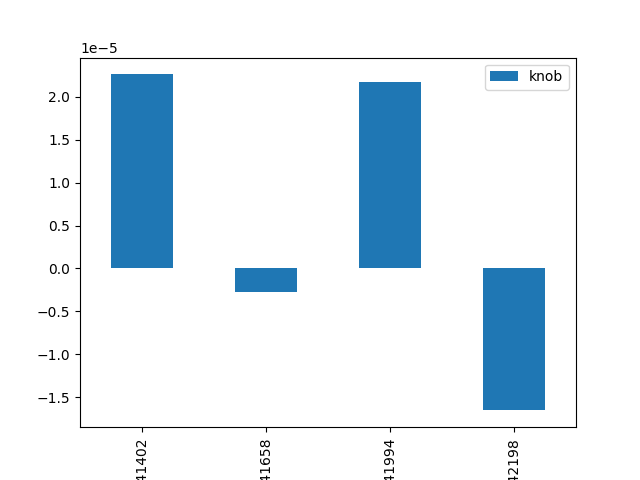

In [24]:
fig, ax = plt.subplots()

line.env["x_teca_knob"] = 0
opt_x_LSS4 = op.set_x_knobLSS4(line)

plot_bump(ax)

settings = {}
for name, knob in bumpers.items():
    settings[name] = line.vv[knob]
    print(name, settings[name])


settings = pd.DataFrame(settings, index=['knob']).T
settings.plot(kind='bar')

In [25]:
for bumper in bumpers:
    print(bumper, line.vv[bumper])

mpsh.41402 -0.0
mplh.41658 -0.0
mplh.41994 -0.0
mpsh.42198 -0.0


# Creating a fine knob for the angle

In [26]:
line.env["x_mm_knob"] =  0 # mm
for bumper, knob in  bumpers.items():
    line.env[bumper + "_x_init_mm"] = copy(line.vv[knob]) #/ (TECA.tilt * 1e6) # mm normalizing the knob to the TECA tilt
    line.vv[knob] = bumper + "_init" + "*  x_teca_knob + " + bumper + "_x_init_mm * x_mm_knob"

# Angle knob

                                             
Optimize - start penalty: 0.0001                            
Matching: model call n. 13 penalty = 4.2817e-13              
Optimize - end penalty:  4.28173e-13                            
mpsh.41402 -6.731633974983806e-07
mplh.41658 6.748354752720832e-07
mplh.41994 -4.112250542088066e-07
mpsh.42198 8.534429774013829e-07


<Axes: >

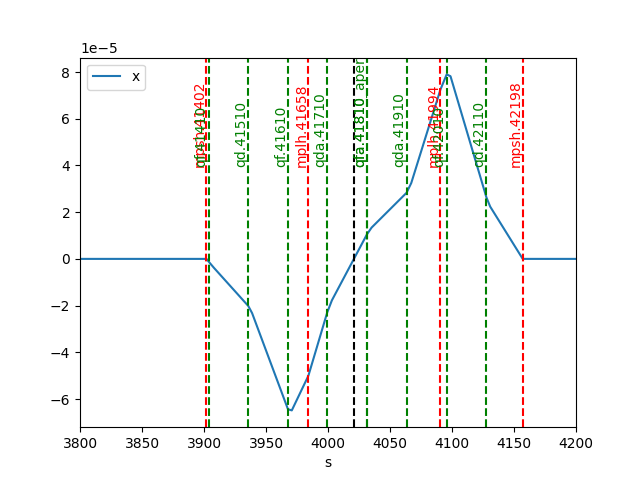

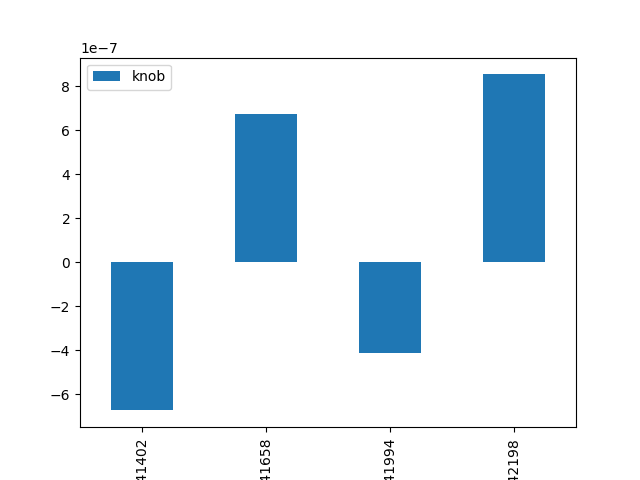

In [27]:
line.vv["x_mm_knob"] =  0
line.vv["x_teca_knob"] =  0


opt_x_LSS4 = op.set_px_knobLSS4(line)

fig, ax = plt.subplots()
plot_bump(ax, show_elements=True)

settings = {}
for name, knob in bumpers.items():
    settings[name] = line.vv[knob]
    print(name, settings[name])

settings = pd.DataFrame(settings, index=['knob']).T
settings.plot(kind='bar')

In [28]:
for bumper in bumpers:
    print(bumper, line.vv[bumper])

mpsh.41402 -0.0
mplh.41658 -0.0
mplh.41994 -0.0
mpsh.42198 -0.0


## Creating the final expression for the knob

In [29]:
line.env["px_knob_murad"] =  0 # mm
for bumper, knob in bumpers.items():
    line.env[bumper + "_init_px"] = copy(line.vv[knob]) # mm normalizing the knob to the TECA tilt
    line.vv[knob] = bumper + "_init" + "*  x_teca_knob + " + bumper + "_x_init_mm * x_mm_knob +" + bumper + "_init_px * px_knob_murad"

## Checking expectation vs reality

In [30]:
np.linspace(-5, 5, 11)

array([-5., -4., -3., -2., -1.,  0.,  1.,  2.,  3.,  4.,  5.])

In [31]:
x_knob_range = np.linspace(-5, 5, 11)
px_knob_range = np.linspace(-5, 5, 11)

line.vv["x_teca_knob"] = 1

results = {}


for i, x_knob in enumerate(x_knob_range):
    for j, px_knob in enumerate(px_knob_range):
        print(i, j, end='\r')
        line.env["x_mm_knob"] = x_knob 
        line.env["px_knob_murad"] = px_knob 
        tw = line.twiss(continue_on_closed_orbit_error=True, method ="4d").to_pandas()
        tw.index = tw.name
        results[i*len(px_knob_range) + j] = {
            "x_mm": tw.loc['TECA.entry'].x * 1e3,  # Convert to mm
            "px_um": tw.loc['TECA.entry'].px * 1e6,  # Convert to um
            "x_knob": tw_init['x', 'TECA.entry']* 1e3 + x_knob,
            "px_knob": tw_init['px', 'TECA.entry']* 1e6 + px_knob,
        }

results_df = pd.DataFrame.from_dict(results, orient='index')

In [32]:
tw_init['x', 'TECA.entry']

np.float64(-0.03999999999994707)

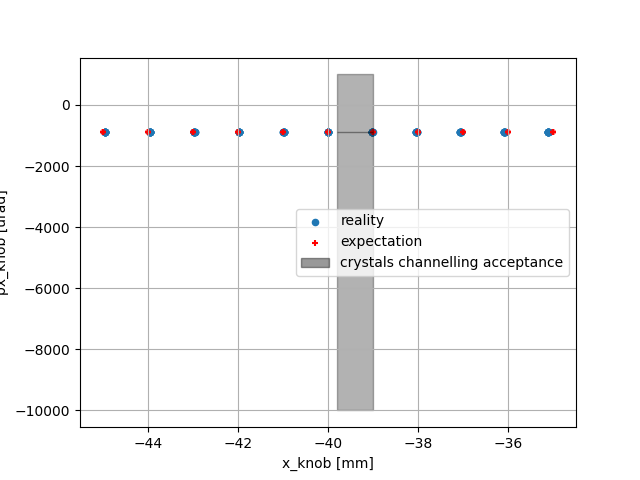

In [33]:
fig, ax = plt.subplots()
results_df.plot.scatter(x='x_mm', y='px_um', marker='o', ax=ax, label='reality')
results_df.plot.scatter(x='x_knob', y='px_knob', marker='+', ax=ax, color='red', label='expectation')
ax.fill_between([TECA.jaw*1e3, TECA.jaw*1e3 - TECA.width*1e3], [TECA.tilt*1e6 - 10]*2, [TECA.tilt*1e6 + 10]*2, color='k', alpha=0.4, label='crystals channelling acceptance')
ax.fill_between([TECA.jaw*1e3, TECA.jaw*1e3 - TECA.width*1e3], -10000, +1000, color='k', alpha=0.3)
ax.set_xlabel('x_knob [mm]')
ax.set_ylabel('px_knob [urad]')
#ax.set_xlim(TECA.jaw*1e3 - TECA.width*1e3 - 4, TECA.jaw*1e3 - TECA.width*1e3 + 2)
#ax.set_ylim(TECA.tilt*1e6 - 27, TECA.tilt*1e6 + 50)
ax.legend()
ax.grid(True)


## Corrector strength when beam is close to the crystal

In [34]:
line.env["x_mm_knob"] = 0 
line.env["px_knob_murad"] = 0
line.env["x_teca_knob"] = 1
        

In [35]:
# fig, ax = plt.subplots()
# plot_bump(ax, show_elements=True)
# ax.set_xlabel('s [m]')
# ax.set_ylabel('x [m]')

# settings = {}
# for name, knob in bumpers.items():
#     settings[name] = line.vv[knob]

# settings = pd.DataFrame(settings, index=['knob']).T
# settings.plot(kind='bar')

In [36]:
for bumper in bumpers:
    print(bumper, line.vv[bumper])

mpsh.41402 -0.00030826188967394275
mplh.41658 -0.0004928762773793241
mplh.41994 -0.0005038850989651299
mpsh.42198 -9.624564390985305e-05


In [37]:
K0_i = copy(np.array([settings.loc[name, 'knob'] for name in bumpers.keys()]))

In [38]:
from copy import copy

K0_i

array([-6.73163397e-07,  6.74835475e-07, -4.11225054e-07,  8.53442977e-07])

# Retreiving Alpha_i for the mm fine orthogonal knob

In [39]:
line.env["x_mm_knob"] = 1
line.env["px_knob_murad"] = 0
line.env["x_teca_knob"] = 1

In [40]:
for bumper in bumpers:
    print(bumper, line.vv[bumper])

mpsh.41402 -0.00030826188967394275
mplh.41658 -0.0004928762773793241
mplh.41994 -0.0005038850989651299
mpsh.42198 -9.624564390985305e-05


In [41]:
alpha_i = [0, 0, 0, 0]
for i, bumper in enumerate(bumpers):
    print( K0_i[i])
    print(line.vv[bumper])
    alpha = K0_i[i] - line.vv[bumper]
    print(f"alpha_{i} = {alpha}")
    alpha_i[i] = alpha

-6.731633974983806e-07
-0.00030826188967394275
alpha_0 = 0.0003075887262764444
6.748354752720832e-07
-0.0004928762773793241
alpha_1 = 0.0004935511128545962
-4.112250542088066e-07
-0.0005038850989651299
alpha_2 = 0.000503473873910921
8.534429774013829e-07
-9.624564390985305e-05
alpha_3 = 9.709908688725443e-05


In [42]:
alpha_i

[np.float64(0.0003075887262764444),
 np.float64(0.0004935511128545962),
 np.float64(0.000503473873910921),
 np.float64(9.709908688725443e-05)]

## Retreiving Beta_i for murads hortogonal knob

# LSS2 bump

In [43]:
line.env["x_mm_knob"] = 0
line.env["px_knob_murad"] = 0
line.env["x_teca_knob"] = 0

In [44]:
# fig, ax = plt.subplots()


# opt_x_LSS4 = op.normalized_x_knobLSS4(line)

# plot_bump(ax)

# settings = {}
# for name, knob in bumpers.items():
#     settings[name] = line.vv[knob]

# settings = pd.DataFrame(settings, index=['knob']).T
# settings.plot(kind='bar')

import optimisers as op
import importlib
importlib.reload(op)

# Set the initial conditions
#optLSS4 = op.horizontal_bumpLSS4_MD(line, x_target = - 40e-3, px_target = -1.5e-3)
#optLSS4 = op.horizontal_bumpLSS4_MD(line)
optLSS2 = op.horizontal_bumpLSS2(line)



optLSS2.log()
optLSS2.solve()

tw = line.twiss(continue_on_closed_orbit_error=True, method ="4d")

                                             
Optimize - start penalty: 0.39                              
Matching: model call n. 22 penalty = 1.0730e-14              
Optimize - end penalty:  1.07304e-14                            
                                             
Optimize - start penalty: 1.073e-14                          
Matching: model call n. 24 penalty = 1.0730e-14              
Optimize - end penalty:  1.07304e-14                            


In [45]:
tw_df = tw.to_pandas()
tw_df.index = tw_df.name
angle_at_TPST = tw_df.loc['tpst.21760_entry'].px 
postion_at_TPST = tw_df.loc['tpst.21760_entry'].x 

In [46]:
bumpersNorth = {
    "mpsh.21202": "kmpsh21202",
    "mplh.21431": "kmplh21431",
    "mpnh.21732": "kmpnh21732",
    "mplh.21995": "kmplh21995",
    "mplh.22195": "kmplh22195"
}

'kmpsh21202', 'kmplh21431', 'kmpnh21732', 'kmplh21995', 'kmplh22195'
'mpsh.21202', 'mplh.21431', 'mpnh.21732', 'mplh.21995', 'mplh.22195'
def plot_bumpLSS2(ax, show_elements=True, **kwargs):
    tw = line.twiss(continue_on_closed_orbit_error=True, method ="4d").to_pandas()
    tw.index = tw.name
    tw.plot(x='s', y='x', ax=ax, **kwargs)
    if show_elements:
        for name in 'mpsh.21202', 'mplh.21431', 'mpnh.21732', 'mplh.21995', 'mplh.22195':
            ax.axvline(tw.loc[name].s, color='r', linestyle='--', label=name)
            ax.text(tw.loc[name].s, tw.x.max()/2, name, rotation=90, verticalalignment='bottom', horizontalalignment='right', color='red')

        for name in tw.loc['mpsh.21202':'mplh.22195'].name:
            if 'q' in name:
                ax.axvline(tw.loc[name].s, color='g', linestyle='--', label=name)
                ax.text(tw.loc[name].s, tw.x.max()/2, name, rotation=90, verticalalignment='bottom', horizontalalignment='right', color='green')

    #ax.set_xlim(3800, 4200)

In [47]:
from copy import copy

tab = line.get_table(attr=True)
line.vars.get_table()
tab.rows["mp.h\.2.*"].cols["k0l"]

bumpersLSS2 = list(line.vars.get_table().rows["kmp.h2.*[0-9]"].name)

for bumper, knob in bumpersNorth.items():
    line.env[bumper + "_init"] = copy(line.vv[knob])

In [48]:
line.env["extraction_knob_LSS2"] = 1.0

In [49]:
for bumper in bumpersNorth:
    line.vv[bumper] = bumper + "_init" + "*  extraction_knob_LSS2"
    print(bumper, line.vv[bumper])

mpsh.21202 2.5049772267447214e-06
mplh.21431 0.0006468291371112276
mpnh.21732 0.0004409254525969997
mplh.21995 0.000645161395812144
mplh.22195 -0.00014950730570318144


2.5049772267447214e-06
0.0006468291371112276
0.0004409254525969997
0.000645161395812144
-0.00014950730570318144


<Axes: >

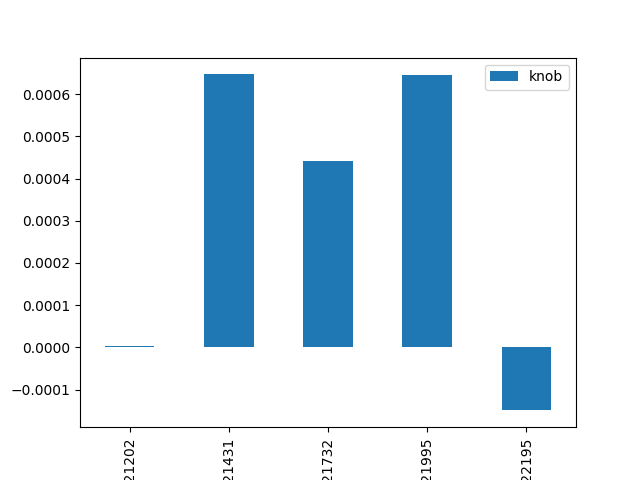

In [50]:
settings = {}
for name, knob in bumpersNorth.items():
    settings[name] = line.vv[knob]
    print(settings[name])

settings = pd.DataFrame(settings, index=['knob']).T
settings.plot(kind='bar')

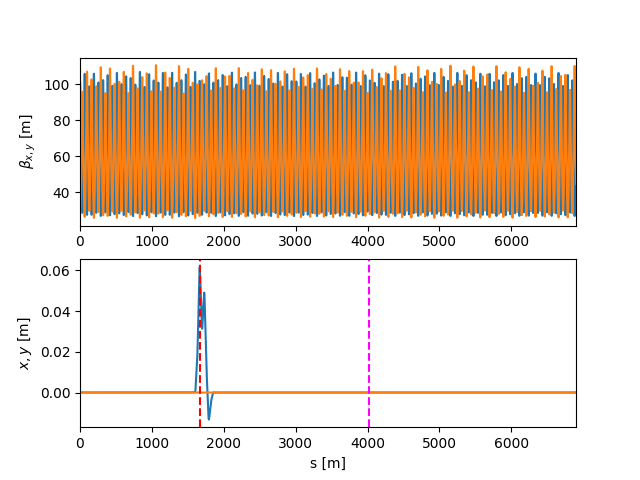

(0.0, 6900.0)

In [51]:
tw_init = line.twiss(continue_on_closed_orbit_error=True, method = '4d')

plt.figure()
ax1 = plt.subplot(2, 1, 1)
plt.plot(tw_init.s, tw_init.betx)
plt.plot(tw_init.s, tw_init.bety)
plt.ylabel(r"$\beta_{x,y}$ [m]")
plt.xlim(0,6900)
ax2 = plt.subplot(2, 1, 2, sharex=ax1)
plt.plot(tw_init.s, tw_init.x)
plt.plot(tw_init.s, tw_init.y)
plt.axvline(tw_init["s", "zs.21633"], color="red", ls="--", label = "ZS entry")
plt.axvline(tw_init["s", "TECA.entry"], color="magenta", ls="--")
plt.ylabel(r"$x,y$ [m]")
plt.xlabel("s [m]")
plt.show()
plt.xlim(0,6900)

In [52]:
print(postion_at_TPST)

0.03899999999996701


# Orthogonal X Knob for LSS2

                                             
Optimize - start penalty: 0.5988                            
Matching: model call n. 62 penalty = 8.4989e-09              
Optimize - end penalty:  8.49887e-09                            
mpsh.21202 -1.66936007693498e-05
mplh.21431 1.917700490886277e-05
mpnh.21732 5.776857766528614e-06
mplh.21995 2.1584615510384897e-05
mplh.22195 8.15163935880695e-06


<Axes: >

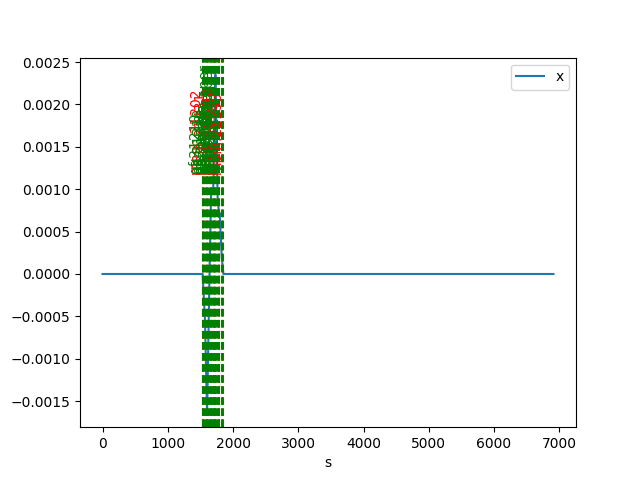

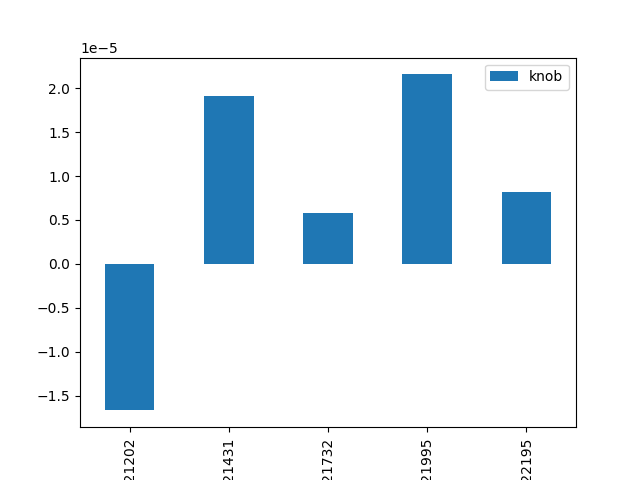

In [53]:

fig, ax = plt.subplots()

line.env["extraction_knob_LSS2"] = 0
opt_x_LSS4 = op.set_x_knobLSS2(line)

plot_bumpLSS2(ax)

settings = {}
for name, knob in bumpersNorth.items():
    settings[name] = line.vv[knob]
    print(name, settings[name])


settings = pd.DataFrame(settings, index=['knob']).T
settings.plot(kind='bar')


In [54]:
line.env["x_mm_knobLSS2"] =  0 # mm
for bumper, knob in  bumpersNorth.items():
    line.env[bumper + "_x_init_mm"] = copy(line.vv[knob]) #/ (TECA.tilt * 1e6) # mm normalizing the knob to the TECA tilt
    line.vv[knob] = bumper + "_init" + "*  extraction_knob_LSS2 + " + bumper + "_x_init_mm * x_mm_knobLSS2"

# Orthogonal PX Knob for LSS2

In [55]:
line.env["x_mm_knob"] = 0
line.env["px_knob_murad"] = 0
line.env["x_teca_knob"] = 0
line.env["extraction_knob_LSS2"] = 0
line.env["x_mm_knobLSS2"] = 0

                                             
Optimize - start penalty: 0.0001                            
Matching: model call n. 15 penalty = 4.7289e-14              
Optimize - end penalty:  4.72894e-14                            
mpsh.21202 2.9767413312215936e-07
mplh.21431 -1.4933162986023825e-07
mpnh.21732 1.6499319575467844e-06
mplh.21995 -3.18227556787172e-07
mplh.22195 8.073530926696783e-07


<Axes: >

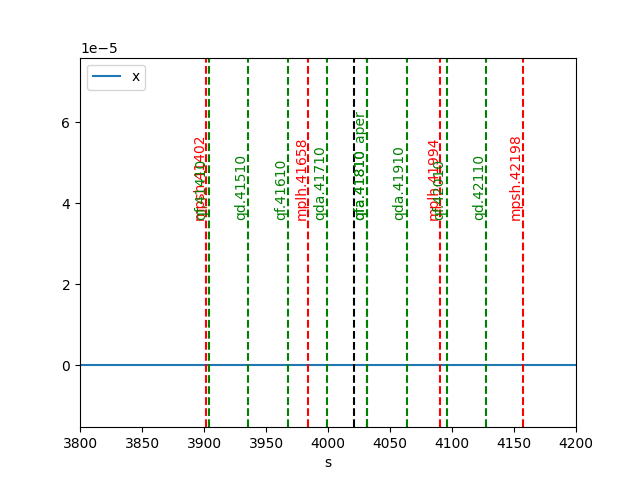

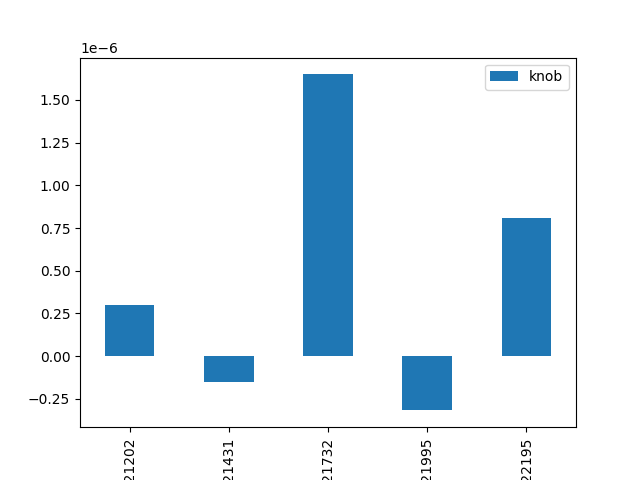

In [56]:
opt_px_LSS2 = op.set_px_knobLSS2(line)

fig, ax = plt.subplots()
plot_bump(ax, show_elements=True)

settings = {}
for name, knob in bumpersNorth.items():
    settings[name] = line.vv[knob]
    print(name, settings[name])

settings = pd.DataFrame(settings, index=['knob']).T
settings.plot(kind='bar')

In [57]:
line.env["px_knob_muradLSS2"] =  0 # murads
for bumper, knob in bumpersNorth.items():
    line.env[bumper + "_init_px"] = copy(line.vv[knob]) 
    line.vv[knob] = bumper + "_init" + "*  extraction_knob_LSS2 + " + bumper + "_x_init_mm * x_mm_knobLSS2 +" + bumper + "_init_px * px_knob_muradLSS2"

# Final check

In [58]:
line.env["x_mm_knob"] = 1
line.env["px_knob_murad"] = 0
line.env["x_teca_knob"] = 1
line.env["extraction_knob_LSS2"] = 1
line.env["x_mm_knobLSS2"] = 1
line.env["px_knob_muradLSS2"] =  0

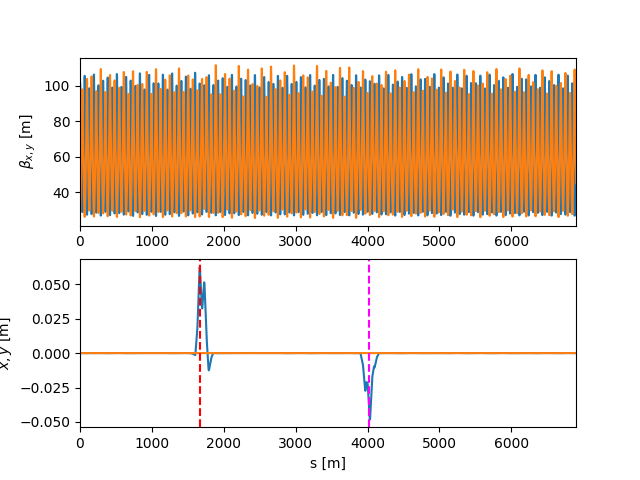

(0.0, 6900.0)

In [59]:
tw_final = line.twiss(continue_on_closed_orbit_error=True, method = '4d')

plt.figure()
ax1 = plt.subplot(2, 1, 1)
plt.plot(tw_final.s, tw_final.betx)
plt.plot(tw_final.s, tw_final.bety)
plt.ylabel(r"$\beta_{x,y}$ [m]")
plt.xlim(0,6900)
ax2 = plt.subplot(2, 1, 2, sharex=ax1)
plt.plot(tw_final.s, tw_final.x)
plt.plot(tw_final.s, tw_final.y)
plt.axvline(tw_final["s", "zs.21633"], color="red", ls="--", label = "ZS ")
plt.axvline(tw_final["s", "TECA.entry"], color="magenta", ls="--", label = "TECA ")
plt.ylabel(r"$x,y$ [m]")
plt.xlabel("s [m]")
plt.show()
plt.xlim(0,6900)